<a href="https://colab.research.google.com/github/DaniJonesOcean/etc-impacts-great-lakes/blob/main/notebooks/Extratropical_cyclone_impacts_on_the_Great_Lakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports and Configuration

In [26]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    PowerTransformer, FunctionTransformer, MinMaxScaler, RobustScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

### Select storm characteristics

In [27]:
storm_characteristics = [
    'min_p_cent',
    'max_p_grad',
    'max_radius',
    'max_uv',
    'fraction_of_time_in_GLR',
    'maturity_glr0_minus_genesis_ratio'
]

### Load Data

In [28]:
def load_datasets(era5_path, cfsr_path, features):
    df_era5 = pd.read_csv(era5_path, usecols=features + ['year', 'month'])
    df_cfsr = pd.read_csv(cfsr_path, usecols=features + ['year', 'month'])
    df_era5 = df_era5.dropna()
    df_cfsr = df_cfsr.dropna()
    return df_era5, df_cfsr

# Set paths
notebook_dir = os.getcwd()
data_dir = os.path.join(notebook_dir, '..', 'data')
era5_path = os.path.join(data_dir, 'era5_etc.csv')
cfsr_path = os.path.join(data_dir, 'cfsr_etc.csv')

# Load
df_era5, df_cfsr = load_datasets(era5_path, cfsr_path, storm_characteristics)


In [29]:
print("ERA5 shape:", df_era5.shape)
print("CFSR shape:", df_cfsr.shape)

# Column check
for df_name, df in zip(['ERA5', 'CFSR'], [df_era5, df_cfsr]):
    missing = [col for col in storm_characteristics if col not in df.columns]
    print(f"{df_name} missing columns:", missing if missing else "✅ All good")

# Summary stats
print("ERA5 Summary:")
display(df_era5[storm_characteristics].describe())
print("CFSR Summary:")
display(df_cfsr[storm_characteristics].describe())


ERA5 shape: (6136, 8)
CFSR shape: (3318, 8)
ERA5 missing columns: ✅ All good
CFSR missing columns: ✅ All good
ERA5 Summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000,6136.000000
mean,987.208117,23.937711,1004.338056,107.322702,0.267445,0.264470
std,14.617619,9.923363,413.263217,26.783662,0.243401,0.275026
min,912.387459,8.254450,250.334294,26.424395,0.000000,0.000000
25%,978.938736,16.182580,693.825600,88.093280,0.083333,0.000000
50%,990.359349,21.861112,966.817911,109.310097,0.200000,0.181818
75%,997.982710,29.998305,1273.436163,129.009322,0.400000,0.428571
max,1021.648576,71.210767,3616.098744,222.052990,1.000000,1.000000


CFSR Summary:


,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio
count,3318.000000,3318.000000,3318.000000,3318.000000,3318.000000,3318.000000
mean,998.715114,16.219137,1029.298861,106.055397,0.261730,0.262920
std,8.375467,6.097138,409.012310,27.781532,0.233043,0.264595
min,957.616172,7.500833,250.731335,27.280463,-0.600000,-0.166667
25%,993.792852,11.620552,722.652821,85.649654,0.090909,0.000000
50%,999.659375,15.022101,994.959088,109.331341,0.200000,0.186773
75%,1004.516387,19.473973,1307.639439,127.872185,0.375000,0.428571
max,1022.841953,44.551383,3234.263229,194.783500,1.000000,0.964912


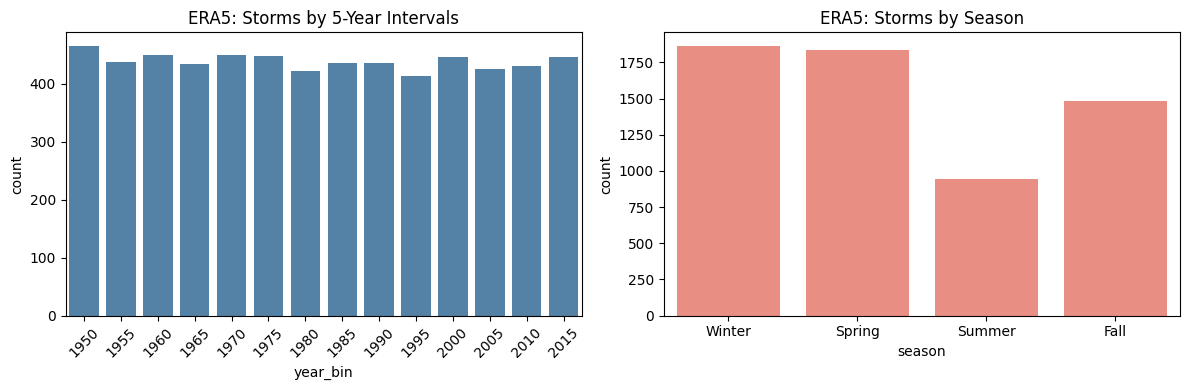

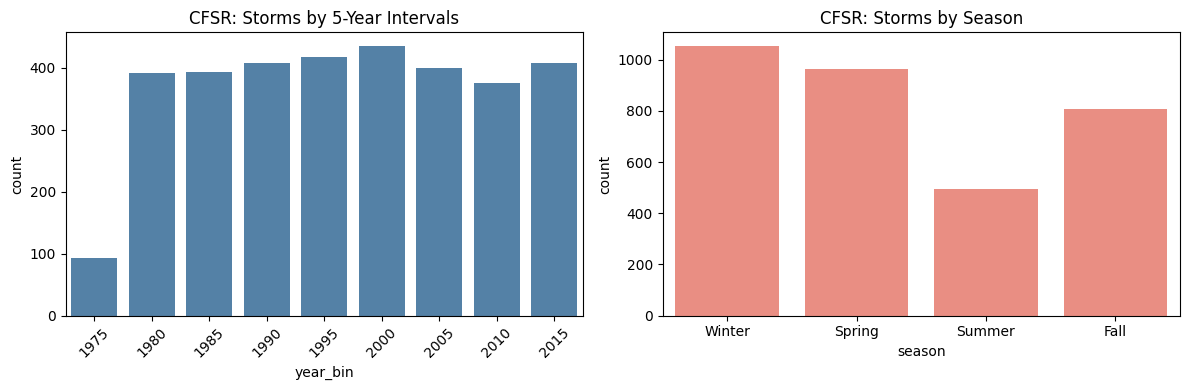

In [ ]:
# Add season
def assign_season(month):
    if month in [12, 1, 2]: return 'DJF'
    if month in [3, 4, 5]: return 'MAM'
    if month in [6, 7, 8]: return 'JJA'
    return 'SON'

for df in [df_era5, df_cfsr]:
    df['season'] = df['month'].apply(assign_season)

# Bin the years into 5-year intervals
df_era5['year_bin'] = (df_era5['year'] // 5) * 5
df_cfsr['year_bin'] = (df_cfsr['year'] // 5) * 5

# Plot using the binned years
for label, df in zip(['ERA5', 'CFSR'], [df_era5, df_cfsr]):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Countplot with binned years
    sns.countplot(data=df, x='year_bin', color='steelblue', ax=axs[0])
    axs[0].set_title(f"{label}: Storms by 5-Year Intervals")
    axs[0].tick_params(axis='x', rotation=45)

    # Seasonal countplot
    sns.countplot(data=df, x='season', order=['Winter', 'Spring', 'Summer', 'Fall'], color='salmon', ax=axs[1])
    axs[1].set_title(f"{label}: Storms by Season")

    plt.tight_layout()
    plt.show()





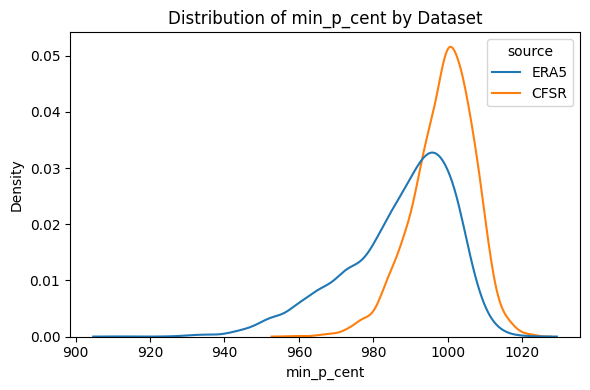

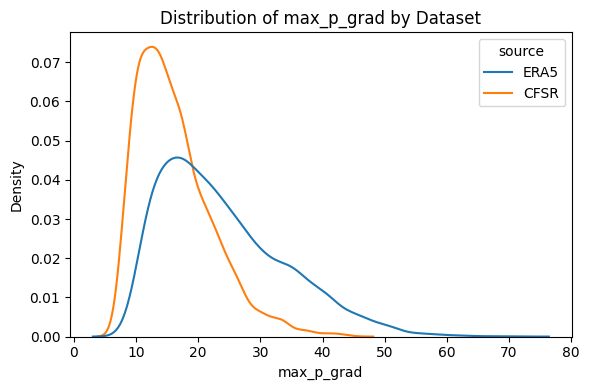

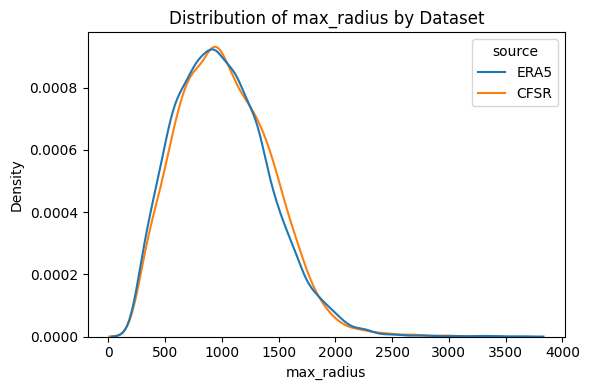

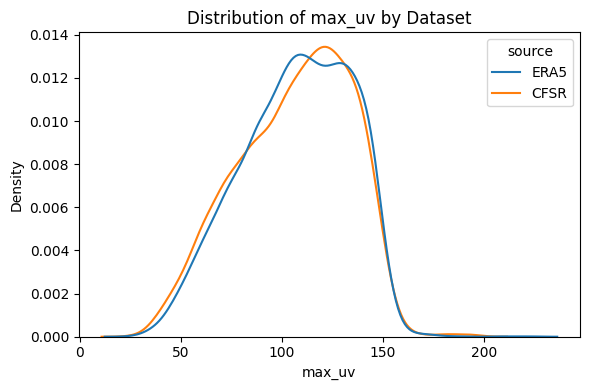

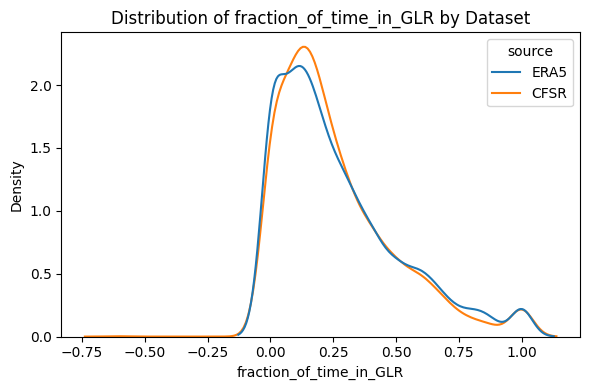

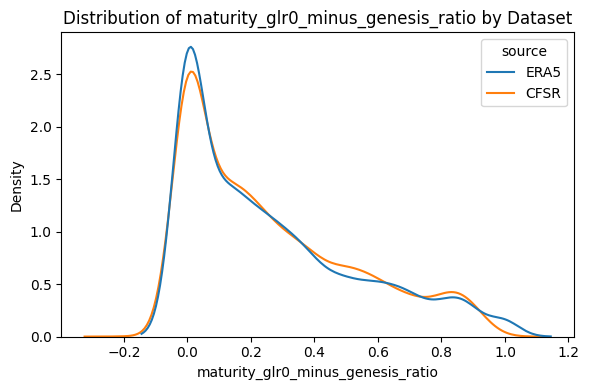

In [37]:
df_era5['source'] = 'ERA5'
df_cfsr['source'] = 'CFSR'
df_all = pd.concat([df_era5, df_cfsr], ignore_index=True)

for var in storm_characteristics:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_all, x=var, hue='source', common_norm=False)
    plt.title(f"Distribution of {var} by Dataset")
    plt.tight_layout()
    plt.show()


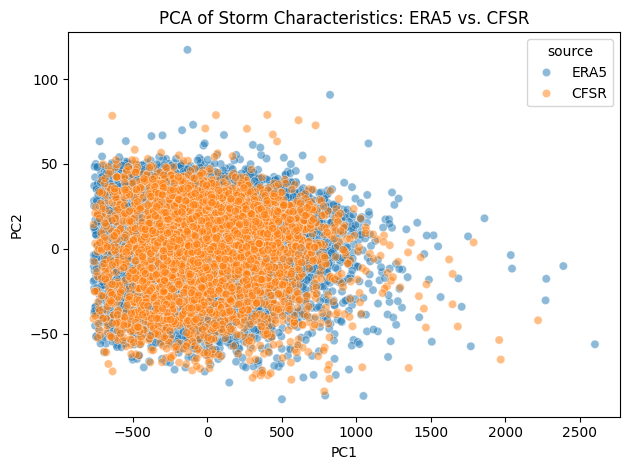

In [32]:
X_combined = df_all[storm_characteristics].values
pca = PCA(n_components=2)
df_all['PC1'], df_all['PC2'] = pca.fit_transform(X_combined).T

sns.scatterplot(data=df_all, x='PC1', y='PC2', hue='source', alpha=0.5)
plt.title("PCA of Storm Characteristics: ERA5 vs. CFSR")
plt.tight_layout()
plt.show()
